In [50]:
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
# Load the model
model = cobra.io.read_sbml_model("../model.xml")

In [52]:
ecoli_model = cobra.io.read_sbml_model("/Users/helenscott/Documents/PhD/Segre-lab/GEM-repos/ecoli/iJO1366.xml")

In [53]:
# Define a minimal media without C or N
minimal_media = {
    "EX_cpd00058_e0": 1000,  # Cu2+_e0
    "EX_cpd00007_e0": 20,  # O2_e0
    "EX_cpd00971_e0": 1000,  # Na+_e0
    "EX_cpd00063_e0": 1000,  # Ca2+_e0
    "EX_cpd00048_e0": 1000,  # Sulfate_e0
    "EX_cpd10516_e0": 1000,  # fe3_e0
    "EX_cpd00254_e0": 1000,  # Mg_e0
    "EX_cpd00009_e0": 1000,  # Phosphate_e0
    "EX_cpd00205_e0": 1000,  # K+_e0
    "EX_cpd00099_e0": 1000,  # Cl-_e0
    "EX_cpd00030_e0": 1000,  # Mn2+_e0
    "EX_cpd00001_e0": 1000,  # H2O_e0
    "EX_cpd00034_e0": 1000,  # Zn2+_e0
    "EX_cpd00149_e0": 1000,  # Co2+_e0
}

In [54]:
# Define carbon sources to test
c_source = {"Glucose": {"modelseed": "EX_cpd00027_e0", "bigg": "EX_glc__D_e"},
            "Acetate": {"modelseed": "EX_cpd00029_e0", "bigg": "EX_ac_e"},
            "Pyruvate": {"modelseed": "EX_cpd00020_e0", "bigg": "EX_pyr_e"},
            "Succinate": {"modelseed": "EX_cpd00036_e0", "bigg": "EX_succ_e"}}

In [55]:
# Define nitrogen sources to test
n_source = {"Ammonia": {"modelseed": "EX_cpd00013_e0", "bigg": "EX_nh4_e"},
            "Nitrate": {"modelseed": "EX_cpd00209_e0", "bigg": "EX_no3_e"}}

In [56]:
# Make a list to store results
results_list = []

# For each carbon and nitrogen source, and proton limit test growth
p_id = "EX_cpd00067_e0"
for p_limit in [0, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["modelseed"]
        # Find the metabolite for the carbon source
        carbon_metabolite = model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["modelseed"]

            # Create a copy of the minimal media
            media = minimal_media.copy()

            # Add the carbon, nitrogen, and proton sources to the media
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000  # Unlimited nitrogen source
            media[p_id] = p_limit

            # Set the minimal media
            model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(model)
            
            # Store the results
            results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "Proton Limit": p_limit,
                "Media": media,
                "Growth Rate": solution.fluxes["bio1_biomass"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
results = pd.DataFrame(results_list)

In [57]:
results

,Carbon Source,Nitrogen Source,Proton Limit,Media,Growth Rate,Fluxes
0,Glucose,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.673652,rxn02201_c0 0.004336 rxn00351_c0 0...
1,Glucose,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.565758,rxn02201_c0 0.003641 rxn00351_c0 0...
2,Acetate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.135752,rxn02201_c0 8.737241e-04 rxn00351_c0 ...
3,Acetate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
4,Pyruvate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.383121,rxn02201_c0 0.002466 rxn00351_c0 0...
5,Pyruvate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.282093,rxn02201_c0 0.001816 rxn00351_c0 0...
6,Succinate,Ammonia,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.239864,rxn02201_c0 0.001544 rxn00351_c0 0...
7,Succinate,Nitrate,0,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.000000,rxn02201_c0 0.0 rxn00351_c0 0.0 rx...
8,Glucose,Ammonia,1000,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.673652,rxn02201_c0 0.004336 rxn00351_c0 0...
9,Glucose,Nitrate,1000,"{'EX_cpd00058_e0': 1000, 'EX_cpd00007_e0': 20,...",0.619265,rxn02201_c0 0.003986 rxn00351_c0 0...


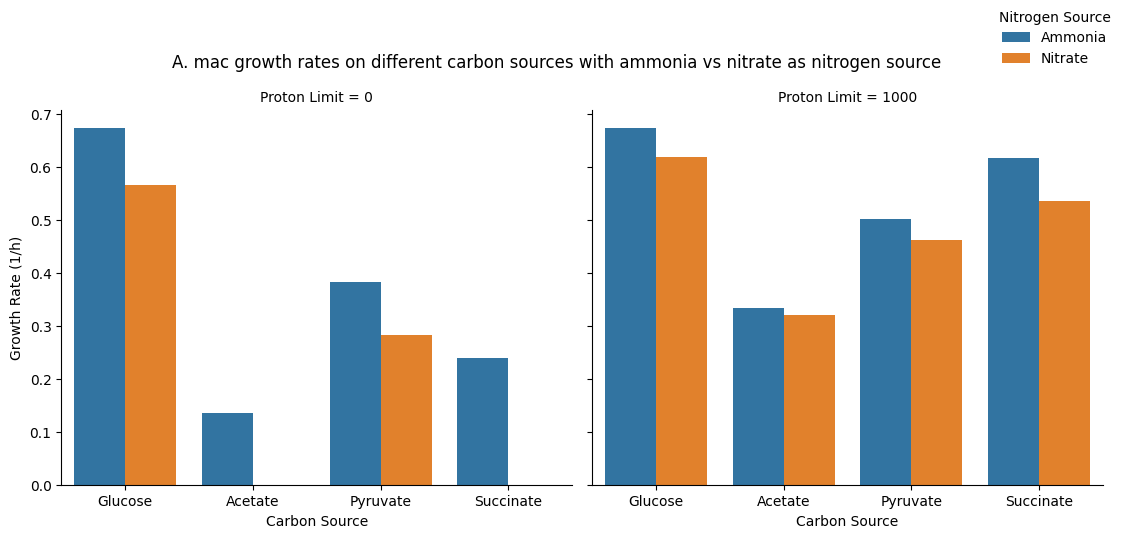

In [58]:
# Plot a series of paired bar charts of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source, with separate charts for each proton limit
g = sns.catplot(
    data=results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="Proton Limit",
)
g.fig.suptitle("A. mac growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()

In [78]:
# Parse the 'Fluxes' column to extract the flux values into a dictionary
results['Fluxes_dict'] = results['Fluxes'].apply(lambda x: x.to_dict())

# Group by carbon and nitrogen source
grouped = results.groupby(['Carbon Source', 'Nitrogen Source'])

# Iterate over each group and compare the fluxes
for name, group in grouped:
    # Separate the two proton limit conditions
    limit_0 = group[group['Proton Limit'] == 0].iloc[0]
    limit_1000 = group[group['Proton Limit'] == 1000].iloc[0]

    # Get the flux dictionaries
    fluxes_0 = limit_0['Fluxes_dict']
    fluxes_1000 = limit_1000['Fluxes_dict']

    # Find reactions with different fluxes
    diff_reactions = {rxn: (fluxes_0.get(rxn, 0), fluxes_1000.get(rxn, 0))
                      for rxn in set(fluxes_0) | set(fluxes_1000)
                      if not pd.isna(fluxes_0.get(rxn, 0)) and not pd.isna(fluxes_1000.get(rxn, 0)) and
                         abs(fluxes_0.get(rxn, 0) - fluxes_1000.get(rxn, 0)) > 1e-6}

    if diff_reactions:
        # Create a DataFrame for the differences
        diff_df = pd.DataFrame.from_dict(diff_reactions, orient='index', columns=['Proton Limit 0', 'Proton Limit 1000'])
        diff_df['Difference'] = diff_df['Proton Limit 1000'] - diff_df['Proton Limit 0']

        # Subset the DataFrame to include only reactions that involve protons
        h_e_diff_df = diff_df[diff_df.index.isin([rxn.id for rxn in model.reactions if model.metabolites.cpd00067_e0 in rxn.metabolites])]

        if not h_e_diff_df.empty:
            print(f"Extracellular Proton Flux differences for {name[0]} with {name[1]}:")
            display(h_e_diff_df)
        else:
            print(f"No extracellular proton flux differences for {name[0]} with {name[1]}")
    else:
        print(f"No flux differences for {name[0]} with {name[1]}")

Extracellular Proton Flux differences for Acetate with Ammonia:


,Proton Limit 0,Proton Limit 1000,Difference
rxn05491_c0,-1.295160,0.000000,1.295160
rxn05488_c0,17.157842,17.780032,0.622190
rxn05595_c0,0.000291,0.000718,0.000427
rxn08173_c0,38.319367,39.049874,0.730507
rxn05209_c0,-0.332096,-0.818561,-0.486465
rxn14420_c0,19.774174,20.464436,0.690261
rxn05618_c0,0.000291,0.000718,0.000427
rxn05651_c0,0.037286,0.091904,0.054618
rxn05514_c0,-0.000291,-0.000718,-0.000427
rxn14427_c0,-12.012823,-7.001152,5.011671


Extracellular Proton Flux differences for Acetate with Nitrate:


,Proton Limit 0,Proton Limit 1000,Difference
rxn05488_c0,0.0,20.778852,20.778852
rxn05595_c0,0.0,0.000688,0.000688
rxn08173_c0,0.0,40.750264,40.750264
rxn05209_c0,0.0,-0.784571,-0.784571
rxn14420_c0,0.0,24.322817,24.322817
rxn05618_c0,0.0,0.000688,0.000688
rxn05651_c0,0.0,0.088088,0.088088
rxn05514_c0,0.0,-0.000688,-0.000688
rxn14426_c0,0.0,15.665486,15.665486
rxn14425_c0,0.0,15.665486,15.665486


Extracellular Proton Flux differences for Glucose with Ammonia:


...

,Proton Limit 0,Proton Limit 1000,Difference
rxn05595_c0,0.000605,0.000993,0.000388
rxn08173_c0,39.286763,38.834236,-0.452527
rxn05209_c0,-0.690095,-1.132745,-0.442650
rxn14420_c0,25.857324,23.057502,-2.799822
rxn05618_c0,0.000605,0.000993,0.000388
rxn05651_c0,0.077480,0.127179,0.049699
rxn05514_c0,-0.000605,-0.000993,-0.000388
rxn14427_c0,-9.078132,-2.059188,7.018943
rxn14421_c0,3.681100,12.617446,8.936346
rxn13688_c0,9.078132,2.059188,-7.018943


Extracellular Proton Flux differences for Succinate with Ammonia:


,Proton Limit 0,Proton Limit 1000,Difference
rxn05491_c0,-2.806527,0.000000,2.806527
rxn05488_c0,0.000000,-0.396345,-0.396345
rxn05595_c0,0.000515,0.001324,0.000809
rxn08173_c0,40.262372,41.998205,1.735834
rxn05209_c0,6.776782,0.000000,-6.776782
rxn14420_c0,12.057349,21.027258,8.969909
rxn05618_c0,0.000515,0.001324,0.000809
rxn05651_c0,0.065882,0.169448,0.103566
rxn05514_c0,-0.000515,-0.001324,-0.000809
rxn14427_c0,-12.878658,-0.758658,12.119999


Extracellular Proton Flux differences for Succinate with Nitrate:


,Proton Limit 0,Proton Limit 1000,Difference
rxn05595_c0,0.0,0.001149,0.001149
rxn08173_c0,0.0,38.027086,38.027086
rxn05209_c0,0.0,-1.309736,-1.309736
rxn14420_c0,0.0,11.541173,11.541173
rxn05618_c0,0.0,0.001149,0.001149
rxn05651_c0,0.0,0.147051,0.147051
rxn05514_c0,0.0,-0.001149,-0.001149
rxn05654_c0,0.0,15.000000,15.000000
rxn14421_c0,0.0,21.463922,21.463922
rxn43657_c0,0.0,0.001149,0.001149


## E. coli

In [59]:
ecoli_minimal_media = {
 'EX_co2_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_k_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_ca2_e': 1000.0,
 'EX_cbl1_e': 0.01,
 'EX_ni2_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_cl_e': 1000.0,
 'EX_pi_e': 1000.0,
 'EX_zn2_e': 1000.0,
 'EX_sel_e': 1000.0,
 'EX_slnt_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_tungs_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_fe3_e': 1000.0
 }

In [60]:
# Make a list to store results
ecoli_results_list = []

# For each carbon and nitrogen source, and proton limit test growth
p_id = "EX_h_e"
for p_limit in [0, 1000]:

    for c_name, c_dict in c_source.items():
        # Extract the modelseed ID for the carbon source
        c_id = c_dict["bigg"]
        # Find the metabolite for the carbon source
        carbon_metabolite = ecoli_model.metabolites.get_by_id(c_id[3:])
        # Get the number of carbons in the carbon source
        n_carbons = carbon_metabolite.elements.get("C", 0)

        for n_name, n_dict in n_source.items():
            # Extract the modelseed ID for the nitrogen source
            n_id = n_dict["bigg"]

            # Create a copy of the minimal media
            media = ecoli_minimal_media.copy()

            # Add the carbon, nitrogen, and protons to the medium
            media[c_id] = 60/n_carbons  # Set the carbon source to 60 mM C
            media[n_id] = 1000
            media[p_id] = p_limit
            
            # Set the minimal media
            ecoli_model.medium = media
            
            # Run pFBA
            solution = cobra.flux_analysis.pfba(ecoli_model)
            
            # Store the results
            ecoli_results_list.append({
                "Carbon Source": c_name,
                "Nitrogen Source": n_name,
                "Proton Limit": p_limit,
                "Media": media,
                "Growth Rate": solution.fluxes["BIOMASS_Ec_iJO1366_core_53p95M"],
                "Fluxes": solution.fluxes
            })

# Create a dataframe from the list of results
ecoli_results = pd.DataFrame(ecoli_results_list)

In [61]:
ecoli_results

,Carbon Source,Nitrogen Source,Proton Limit,Media,Growth Rate,Fluxes
0,Glucose,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372,EX_cm_e 0.000000 EX_cmp_e 0.0...
1,Glucose,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.779840,EX_cm_e 0.000000 EX_cmp_e 0.0...
2,Acetate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.534681,EX_cm_e 0.000000 EX_cmp_e 0.0...
3,Acetate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.386570,EX_cm_e 0.000000 EX_cmp_e 0.0...
4,Pyruvate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.617273,EX_cm_e 0.000000 EX_cmp_e 0.0...
5,Pyruvate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.448744,EX_cm_e 0.000000 EX_cmp_e 0.0...
6,Succinate,Ammonia,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.521589,EX_cm_e 0.000000 EX_cmp_e 0.0...
7,Succinate,Nitrate,0,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.374848,EX_cm_e 0.000000 EX_cmp_e 0.0...
8,Glucose,Ammonia,1000,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.982372,EX_cm_e 0.000000 EX_cmp_e 0.0...
9,Glucose,Nitrate,1000,"{'EX_co2_e': 1000.0, 'EX_cobalt2_e': 1000.0, '...",0.849220,EX_cm_e 0.000000 EX_cmp_e 0.0...


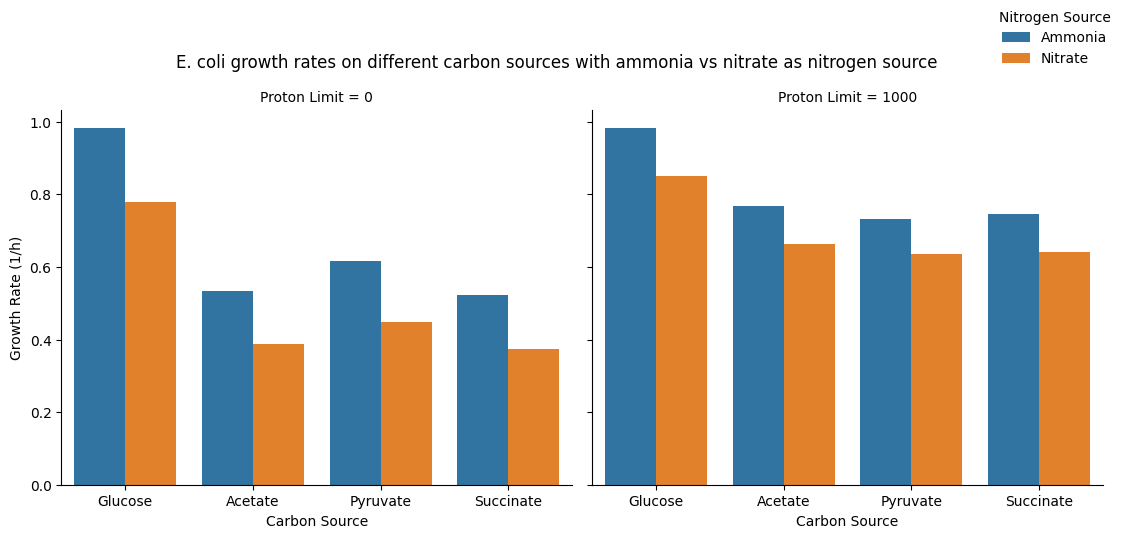

In [62]:
# Plot a paired bar chart of growth rates for each carbon source with ammonia vs nitrate as the nitrogen source
g = sns.catplot(
    data=ecoli_results, kind="bar",
    x="Carbon Source", y="Growth Rate", hue="Nitrogen Source",
    col="Proton Limit",
)
g.fig.suptitle("E. coli growth rates on different carbon sources with ammonia vs nitrate as nitrogen source")
g.set_axis_labels("Carbon Source", "Growth Rate (1/h)")
g.legend.set_title("Nitrogen Source")
# Move the legend to the top right corner
g._legend.set_bbox_to_anchor((1, 1))

plt.tight_layout()
plt.show()